<a href="https://colab.research.google.com/github/thanhmxtran-source/customer-spending-analysis/blob/main/Customer_Spending_Analysis_and_Monthly_Spending.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Spending Analysis and Sales Regression

**Task**: Analyze the relationship between customer demographics and their spending patterns to help a retail store optimize its sales strategies.

### Data Extraction
- Extract customer transaction data from a **JSON** file using **pandas**.

### Pre-Processing
- **Clean the Data**: Handle missing values, create new features such as monthly spend per monthly income, and convert categorical variables (e.g., gender, region) into numerical format.

### Data Summary
- Use **pandas** to generate summary statistics for key metrics (e.g., mean, median of monthly spend).
- **Visualization**:
    - Create histograms of numerical variables.
    - Visualize the distribution of spending relative to the categorical feature variables using boxplots.
    - Calculate pairwise correlations and create a heatmap of the values
    - Generate a scatterplot matrix to show pairwise scatterplots.

### Statistical Modeling
- Use **statsmodels** to build a **multiple linear regression model** to predict customer spending based on demographics (e.g., age, income, region).
- **Interpretation**: Analyze model coefficients to identify key drivers of spending and use the information to make business recommendations.

---

### The data has the following structure.

```
[
    {
        "customer_id": "CUST_1",
        "age": 56,
        "gender": "M",
        "region": "South",
        "income": "$68,900.00",
        "monthly_spend": "$154.82"
    },
    {
        "customer_id": "CUST_2",
        "age": 69,
        "gender": "M",
        "region": "West",
        "income": "$78,300.00",
        "monthly_spend": "$160.97"
    },
    {
        "customer_id": "CUST_3",
        "age": 46,
        "gender": "M",
        "region": "West",
        "income": "$40,000.00",
        "monthly_spend": "$141.76"
    },
    ...
]

```

### Converting JSON Data to a DataFrame

Run the code block below to store the data as `customers_json`.

In [ ]:
# @title
customers_json="""
[
  {
    "customer_id": "CUST_1",
    "age": 56,
    "gender": "M",
    "region": "South",
    "income": "$68,900.00",
    "monthly_spend": "$154.82"
  },
  {
    "customer_id": "CUST_2",
    "age": 69,
    "gender": "M",
    "region": "West",
    "income": "$78,300.00",
    "monthly_spend": "$160.97"
  },
  {
    "customer_id": "CUST_3",
    "age": 46,
    "gender": "M",
    "region": "West",
    "income": "$40,000.00",
    "monthly_spend": "$141.76"
  },
  {
    "customer_id": "CUST_4",
    "age": 32,
    "gender": "M",
    "region": "North",
    "income": "$30,200.00",
    "monthly_spend": "$102.35"
  },
  {
    "customer_id": "CUST_5",
    "age": 60,
    "gender": "M",
    "region": "South",
    "income": "$73,900.00",
    "monthly_spend": "$207.71"
  },
  {
    "customer_id": "CUST_6",
    "age": 25,
    "gender": "F",
    "region": "West",
    "income": "$36,100.00",
    "monthly_spend": "$95.25"
  },
  {
    "customer_id": "CUST_7",
    "age": 38,
    "gender": "M",
    "region": "North",
    "income": null,
    "monthly_spend": "$nan"
  },
  {
    "customer_id": "CUST_8",
    "age": 56,
    "gender": "F",
    "region": "South",
    "income": "$58,300.00",
    "monthly_spend": "$180.21"
  },
  {
    "customer_id": "CUST_9",
    "age": 36,
    "gender": "F",
    "region": "East",
    "income": "$39,600.00",
    "monthly_spend": "$120.70"
  },
  {
    "customer_id": "CUST_10",
    "age": 40,
    "gender": "F",
    "region": "North",
    "income": "$51,200.00",
    "monthly_spend": "$149.48"
  },
  {
    "customer_id": "CUST_11",
    "age": 28,
    "gender": "M",
    "region": "West",
    "income": "$45,500.00",
    "monthly_spend": "$163.53"
  },
  {
    "customer_id": "CUST_12",
    "age": 28,
    "gender": "M",
    "region": "East",
    "income": "$33,700.00",
    "monthly_spend": "$107.85"
  },
  {
    "customer_id": "CUST_13",
    "age": 41,
    "gender": "M",
    "region": "East",
    "income": "$57,700.00",
    "monthly_spend": "$153.59"
  },
  {
    "customer_id": "CUST_14",
    "age": 53,
    "gender": "M",
    "region": "East",
    "income": "$66,700.00",
    "monthly_spend": "$158.25"
  },
  {
    "customer_id": "CUST_15",
    "age": 57,
    "gender": "F",
    "region": "North",
    "income": "$64,100.00",
    "monthly_spend": "$214.89"
  },
  {
    "customer_id": "CUST_16",
    "age": 41,
    "gender": "M",
    "region": "West",
    "income": "$31,600.00",
    "monthly_spend": "$114.65"
  },
  {
    "customer_id": "CUST_17",
    "age": 20,
    "gender": "M",
    "region": "East",
    "income": "$14,700.00",
    "monthly_spend": "$88.62"
  },
  {
    "customer_id": "CUST_18",
    "age": 39,
    "gender": "M",
    "region": "South",
    "income": "$51,400.00",
    "monthly_spend": "$146.56"
  },
  {
    "customer_id": "CUST_19",
    "age": 19,
    "gender": "M",
    "region": "East",
    "income": "$6,900.00",
    "monthly_spend": "$123.91"
  },
  {
    "customer_id": "CUST_20",
    "age": 41,
    "gender": "M",
    "region": "East",
    "income": "$47,200.00",
    "monthly_spend": "$88.24"
  },
  {
    "customer_id": "CUST_21",
    "age": 61,
    "gender": "F",
    "region": "North",
    "income": "$76,000.00",
    "monthly_spend": "$285.70"
  },
  {
    "customer_id": "CUST_22",
    "age": 47,
    "gender": "M",
    "region": "North",
    "income": "$53,500.00",
    "monthly_spend": "$160.45"
  },
  {
    "customer_id": "CUST_23",
    "age": 55,
    "gender": "F",
    "region": "West",
    "income": "$54,000.00",
    "monthly_spend": "$195.40"
  },
  {
    "customer_id": "CUST_24",
    "age": 19,
    "gender": "M",
    "region": "South",
    "income": "$15,500.00",
    "monthly_spend": "$72.56"
  },
  {
    "customer_id": "CUST_25",
    "age": 38,
    "gender": "F",
    "region": "North",
    "income": null,
    "monthly_spend": "$nan"
  },
  {
    "customer_id": "CUST_26",
    "age": 50,
    "gender": "M",
    "region": "East",
    "income": "$59,700.00",
    "monthly_spend": "$160.57"
  },
  {
    "customer_id": "CUST_27",
    "age": 29,
    "gender": "M",
    "region": "West",
    "income": null,
    "monthly_spend": "$nan"
  },
  {
    "customer_id": "CUST_28",
    "age": 39,
    "gender": "F",
    "region": "East",
    "income": "$54,700.00",
    "monthly_spend": "$188.40"
  },
  {
    "customer_id": "CUST_29",
    "age": 61,
    "gender": "F",
    "region": "East",
    "income": "$74,500.00",
    "monthly_spend": "$269.57"
  },
  {
    "customer_id": "CUST_30",
    "age": 42,
    "gender": "F",
    "region": "North",
    "income": "$64,900.00",
    "monthly_spend": "$216.97"
  },
  {
    "customer_id": "CUST_31",
    "age": 66,
    "gender": "M",
    "region": "West",
    "income": "$76,700.00",
    "monthly_spend": "$171.68"
  },
  {
    "customer_id": "CUST_32",
    "age": 44,
    "gender": "F",
    "region": "South",
    "income": "$47,400.00",
    "monthly_spend": "$137.99"
  },
  {
    "customer_id": "CUST_33",
    "age": 59,
    "gender": "M",
    "region": "South",
    "income": "$62,600.00",
    "monthly_spend": "$161.65"
  },
  {
    "customer_id": "CUST_34",
    "age": 45,
    "gender": "M",
    "region": "North",
    "income": "$30,700.00",
    "monthly_spend": "$214.20"
  },
  {
    "customer_id": "CUST_35",
    "age": 33,
    "gender": "F",
    "region": "North",
    "income": "$39,500.00",
    "monthly_spend": "$104.81"
  },
  {
    "customer_id": "CUST_36",
    "age": 32,
    "gender": "F",
    "region": "West",
    "income": "$36,800.00",
    "monthly_spend": "$123.93"
  },
  {
    "customer_id": "CUST_37",
    "age": 64,
    "gender": "M",
    "region": "South",
    "income": "$55,700.00",
    "monthly_spend": "$183.65"
  },
  {
    "customer_id": "CUST_38",
    "age": 68,
    "gender": "M",
    "region": "South",
    "income": "$72,700.00",
    "monthly_spend": "$185.24"
  },
  {
    "customer_id": "CUST_39",
    "age": 61,
    "gender": "F",
    "region": "South",
    "income": "$79,400.00",
    "monthly_spend": "$229.05"
  },
  {
    "customer_id": "CUST_40",
    "age": 69,
    "gender": "F",
    "region": "East",
    "income": "$66,700.00",
    "monthly_spend": "$308.71"
  },
  {
    "customer_id": "CUST_41",
    "age": 20,
    "gender": "F",
    "region": "South",
    "income": null,
    "monthly_spend": "$nan"
  },
  {
    "customer_id": "CUST_42",
    "age": 54,
    "gender": "M",
    "region": "East",
    "income": "$70,000.00",
    "monthly_spend": "$165.64"
  },
  {
    "customer_id": "CUST_43",
    "age": 68,
    "gender": "M",
    "region": "West",
    "income": "$79,300.00",
    "monthly_spend": "$196.70"
  },
  {
    "customer_id": "CUST_44",
    "age": 24,
    "gender": "M",
    "region": "East",
    "income": "$59,600.00",
    "monthly_spend": "$95.68"
  },
  {
    "customer_id": "CUST_45",
    "age": 38,
    "gender": "M",
    "region": "West",
    "income": "$29,800.00",
    "monthly_spend": "$85.88"
  },
  {
    "customer_id": "CUST_46",
    "age": 26,
    "gender": "M",
    "region": "South",
    "income": "$38,200.00",
    "monthly_spend": "$114.83"
  },
  {
    "customer_id": "CUST_47",
    "age": 56,
    "gender": "M",
    "region": "South",
    "income": "$64,200.00",
    "monthly_spend": "$211.44"
  },
  {
    "customer_id": "CUST_48",
    "age": 35,
    "gender": "F",
    "region": "West",
    "income": "$40,600.00",
    "monthly_spend": "$172.79"
  },
  {
    "customer_id": "CUST_49",
    "age": 21,
    "gender": "M",
    "region": "North",
    "income": "$35,100.00",
    "monthly_spend": "$101.30"
  },
  {
    "customer_id": "CUST_50",
    "age": 42,
    "gender": "M",
    "region": "West",
    "income": "$46,700.00",
    "monthly_spend": "$138.42"
  },
  {
    "customer_id": "CUST_51",
    "age": 31,
    "gender": "M",
    "region": "North",
    "income": "$16,600.00",
    "monthly_spend": "$98.34"
  },
  {
    "customer_id": "CUST_52",
    "age": 67,
    "gender": "F",
    "region": "East",
    "income": "$63,500.00",
    "monthly_spend": "$275.39"
  },
  {
    "customer_id": "CUST_53",
    "age": 26,
    "gender": "M",
    "region": "East",
    "income": "$44,600.00",
    "monthly_spend": "$98.66"
  },
  {
    "customer_id": "CUST_54",
    "age": 43,
    "gender": "M",
    "region": "East",
    "income": "$59,700.00",
    "monthly_spend": "$110.43"
  },
  {
    "customer_id": "CUST_55",
    "age": 19,
    "gender": "F",
    "region": "South",
    "income": "$20,300.00",
    "monthly_spend": "$63.84"
  },
  {
    "customer_id": "CUST_56",
    "age": 37,
    "gender": "M",
    "region": "East",
    "income": "$47,000.00",
    "monthly_spend": "$130.98"
  },
  {
    "customer_id": "CUST_57",
    "age": 45,
    "gender": "M",
    "region": "North",
    "income": "$77,800.00",
    "monthly_spend": "$182.92"
  },
  {
    "customer_id": "CUST_58",
    "age": 64,
    "gender": "M",
    "region": "East",
    "income": "$68,700.00",
    "monthly_spend": "$186.29"
  },
  {
    "customer_id": "CUST_59",
    "age": 24,
    "gender": "M",
    "region": "West",
    "income": null,
    "monthly_spend": "$nan"
  },
  {
    "customer_id": "CUST_60",
    "age": 61,
    "gender": "M",
    "region": "West",
    "income": "$67,900.00",
    "monthly_spend": "$186.91"
  },
  {
    "customer_id": "CUST_61",
    "age": 25,
    "gender": "F",
    "region": "South",
    "income": "$36,100.00",
    "monthly_spend": "$143.27"
  },
  {
    "customer_id": "CUST_62",
    "age": 64,
    "gender": "F",
    "region": "West",
    "income": "$65,500.00",
    "monthly_spend": "$259.23"
  },
  {
    "customer_id": "CUST_63",
    "age": 52,
    "gender": "F",
    "region": "North",
    "income": "$63,100.00",
    "monthly_spend": "$250.53"
  },
  {
    "customer_id": "CUST_64",
    "age": 31,
    "gender": "M",
    "region": "East",
    "income": "$16,600.00",
    "monthly_spend": "$80.94"
  },
  {
    "customer_id": "CUST_65",
    "age": 34,
    "gender": "M",
    "region": "South",
    "income": "$42,400.00",
    "monthly_spend": "$63.71"
  },
  {
    "customer_id": "CUST_66",
    "age": 53,
    "gender": "M",
    "region": "East",
    "income": "$58,500.00",
    "monthly_spend": "$149.96"
  },
  {
    "customer_id": "CUST_67",
    "age": 67,
    "gender": "F",
    "region": "East",
    "income": "$69,800.00",
    "monthly_spend": "$207.89"
  },
  {
    "customer_id": "CUST_68",
    "age": 57,
    "gender": "M",
    "region": "North",
    "income": "$57,200.00",
    "monthly_spend": "$184.90"
  },
  {
    "customer_id": "CUST_69",
    "age": 21,
    "gender": "M",
    "region": "West",
    "income": null,
    "monthly_spend": "$nan"
  },
  {
    "customer_id": "CUST_70",
    "age": 19,
    "gender": "F",
    "region": "West",
    "income": "$15,900.00",
    "monthly_spend": "$51.42"
  },
  {
    "customer_id": "CUST_71",
    "age": 23,
    "gender": "M",
    "region": "East",
    "income": "$4,800.00",
    "monthly_spend": "$72.54"
  },
  {
    "customer_id": "CUST_72",
    "age": 59,
    "gender": "F",
    "region": "South",
    "income": "$61,300.00",
    "monthly_spend": "$171.41"
  },
  {
    "customer_id": "CUST_73",
    "age": 21,
    "gender": "F",
    "region": "West",
    "income": "$37,000.00",
    "monthly_spend": "$181.68"
  },
  {
    "customer_id": "CUST_74",
    "age": 46,
    "gender": "F",
    "region": "South",
    "income": "$47,600.00",
    "monthly_spend": "$200.97"
  },
  {
    "customer_id": "CUST_75",
    "age": 35,
    "gender": "M",
    "region": "West",
    "income": null,
    "monthly_spend": "$nan"
  },
  {
    "customer_id": "CUST_76",
    "age": 43,
    "gender": "M",
    "region": "South",
    "income": "$37,200.00",
    "monthly_spend": "$146.50"
  },
  {
    "customer_id": "CUST_77",
    "age": 61,
    "gender": "M",
    "region": "North",
    "income": "$52,900.00",
    "monthly_spend": "$188.95"
  },
  {
    "customer_id": "CUST_78",
    "age": 51,
    "gender": "M",
    "region": "South",
    "income": null,
    "monthly_spend": "$nan"
  },
  {
    "customer_id": "CUST_79",
    "age": 27,
    "gender": "M",
    "region": "North",
    "income": "$21,700.00",
    "monthly_spend": "$87.86"
  },
  {
    "customer_id": "CUST_80",
    "age": 53,
    "gender": "M",
    "region": "North",
    "income": "$46,200.00",
    "monthly_spend": "$117.10"
  },
  {
    "customer_id": "CUST_81",
    "age": 31,
    "gender": "M",
    "region": "South",
    "income": "$40,500.00",
    "monthly_spend": "$95.58"
  },
  {
    "customer_id": "CUST_82",
    "age": 48,
    "gender": "F",
    "region": "North",
    "income": "$70,800.00",
    "monthly_spend": "$203.15"
  },
  {
    "customer_id": "CUST_83",
    "age": 65,
    "gender": "M",
    "region": "East",
    "income": "$63,300.00",
    "monthly_spend": "$115.04"
  },
  {
    "customer_id": "CUST_84",
    "age": 32,
    "gender": "F",
    "region": "North",
    "income": "$20,100.00",
    "monthly_spend": "$177.60"
  },
  {
    "customer_id": "CUST_85",
    "age": 25,
    "gender": "M",
    "region": "West",
    "income": "$36,600.00",
    "monthly_spend": "$58.38"
  },
  {
    "customer_id": "CUST_86",
    "age": 31,
    "gender": "M",
    "region": "South",
    "income": "$21,600.00",
    "monthly_spend": "$122.28"
  },
  {
    "customer_id": "CUST_87",
    "age": 40,
    "gender": "M",
    "region": "East",
    "income": "$33,200.00",
    "monthly_spend": "$122.40"
  },
  {
    "customer_id": "CUST_88",
    "age": 57,
    "gender": "F",
    "region": "South",
    "income": "$66,900.00",
    "monthly_spend": "$228.90"
  },
  {
    "customer_id": "CUST_89",
    "age": 38,
    "gender": "F",
    "region": "West",
    "income": "$41,300.00",
    "monthly_spend": "$150.61"
  },
  {
    "customer_id": "CUST_90",
    "age": 33,
    "gender": "F",
    "region": "West",
    "income": "$31,100.00",
    "monthly_spend": "$156.62"
  },
  {
    "customer_id": "CUST_91",
    "age": 62,
    "gender": "F",
    "region": "West",
    "income": "$67,700.00",
    "monthly_spend": "$214.57"
  },
  {
    "customer_id": "CUST_92",
    "age": 35,
    "gender": "M",
    "region": "North",
    "income": "$35,900.00",
    "monthly_spend": "$106.55"
  },
  {
    "customer_id": "CUST_93",
    "age": 64,
    "gender": "F",
    "region": "North",
    "income": "$87,900.00",
    "monthly_spend": "$217.77"
  },
  {
    "customer_id": "CUST_94",
    "age": 41,
    "gender": "M",
    "region": "South",
    "income": "$39,200.00",
    "monthly_spend": "$169.25"
  },
  {
    "customer_id": "CUST_95",
    "age": 43,
    "gender": "M",
    "region": "South",
    "income": null,
    "monthly_spend": "$nan"
  },
  {
    "customer_id": "CUST_96",
    "age": 42,
    "gender": "F",
    "region": "East",
    "income": "$42,400.00",
    "monthly_spend": "$181.27"
  },
  {
    "customer_id": "CUST_97",
    "age": 62,
    "gender": "F",
    "region": "East",
    "income": "$62,900.00",
    "monthly_spend": "$198.33"
  },
  {
    "customer_id": "CUST_98",
    "age": 58,
    "gender": "F",
    "region": "South",
    "income": "$69,000.00",
    "monthly_spend": "$215.32"
  },
  {
    "customer_id": "CUST_99",
    "age": 46,
    "gender": "F",
    "region": "North",
    "income": "$31,100.00",
    "monthly_spend": "$142.83"
  },
  {
    "customer_id": "CUST_100",
    "age": 32,
    "gender": "F",
    "region": "West",
    "income": null,
    "monthly_spend": "$nan"
  }
]
"""

###Import the necessary libraries

In [ ]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as smf


### Converting JSON Data to a DataFrame

- Load customer spending data from a JSON file into a Python object.
- Convert the data to a Pandas DataFrame.

In [ ]:
# Convert the data from JSON format into a Python object
data = json.loads(customers_json)

# Convert data to DataFrame
df = pd.DataFrame(data)

# Examine the first few rows of the data frame
df.head()

,customer_id,age,gender,region,income,monthly_spend
0,CUST_1,56,M,South,"$68,900.00",$154.82
1,CUST_2,69,M,West,"$78,300.00",$160.97
2,CUST_3,46,M,West,"$40,000.00",$141.76
3,CUST_4,32,M,North,"$30,200.00",$102.35
4,CUST_5,60,M,South,"$73,900.00",$207.71


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    100 non-null    object
 1   age            100 non-null    int64 
 2   gender         100 non-null    object
 3   region         100 non-null    object
 4   income         90 non-null     object
 5   monthly_spend  100 non-null    object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB


### Convert to float
Handle the income and monthly spend variables by removing the `$` symbol, comma and converting to a float data type.

In [ ]:
# Remove dollar signs and commas for numerical varibles
df['income'] = df['income'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['monthly_spend'] = df['monthly_spend'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    100 non-null    object 
 1   age            100 non-null    int64  
 2   gender         100 non-null    object 
 3   region         100 non-null    object 
 4   income         90 non-null     float64
 5   monthly_spend  90 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 4.8+ KB


### Handling Missing Values
Clean and preprocess the customer spending dataset to handle missing values effectively.
- **Compute Median Values:** Calculate the median for `income` and `monthly_spend`.
- **Impute Missing Values:**
   - Replace missing `income`, `monthly_spend` values with their respective medians.

In [ ]:
# Handle missing values by filling with median
median_income = df['income'].median()
median_monthly_spend = df['monthly_spend'].median()

df['income'] = df['income'].fillna(median_income)
df['monthly_spend'] = df['monthly_spend'].fillna(median_monthly_spend)

# Examine the data frame
df.head()

,customer_id,age,gender,region,income,monthly_spend
0,CUST_1,56,M,South,68900.0,154.82
1,CUST_2,69,M,West,78300.0,160.97
2,CUST_3,46,M,West,40000.0,141.76
3,CUST_4,32,M,North,30200.0,102.35
4,CUST_5,60,M,South,73900.0,207.71


In [ ]:
# Check again to make sure we handled all missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    100 non-null    object 
 1   age            100 non-null    int64  
 2   gender         100 non-null    object 
 3   region         100 non-null    object 
 4   income         100 non-null    float64
 5   monthly_spend  100 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 4.8+ KB


### Feature Engineering
Add a new variable to measure monthly spend per monthly income.


In [ ]:
def monthly_spend_per_monthly_income(row):
    monthly_spend = row['monthly_spend']
    monthly_income = row['income'] / 12

    # Check for missing or zero monthly income
    if monthly_income != 0:
        return monthly_spend / monthly_income
    else:
        return 0

# Adding the new column to the DataFrame
df['monthly_spend_per_monthly_income'] = df.apply(monthly_spend_per_monthly_income, axis=1)
df.head()

,customer_id,age,gender,region,income,monthly_spend,monthly_spend_per_monthly_income
0,CUST_1,56,M,South,68900.0,154.82,0.026964
1,CUST_2,69,M,West,78300.0,160.97,0.024670
2,CUST_3,46,M,West,40000.0,141.76,0.042528
3,CUST_4,32,M,North,30200.0,102.35,0.040669
4,CUST_5,60,M,South,73900.0,207.71,0.033728


###Data Summary
Calculate a statistical summary of the data



In [ ]:
# Overall Data Summary
summary_stats = df.describe()
print("Summary Statistics:\n", summary_stats)

Summary Statistics:
               age        income  monthly_spend  \
count  100.000000    100.000000     100.000000   
mean    43.350000  49359.000000     156.699700   
std     14.904663  18103.078007      52.240414   
min     19.000000   4800.000000      51.420000   
25%     31.750000  36950.000000     116.585000   
50%     42.000000  49400.000000     157.435000   
75%     57.000000  63650.000000     186.445000   
max     69.000000  87900.000000     308.710000   

       monthly_spend_per_monthly_income  
count                        100.000000  
mean                           0.043152  
std                            0.025974  
min                            0.018031  
25%                            0.032909  
50%                            0.038243  
75%                            0.043881  
max                            0.215496  


###Summary of Results
**Age**:

The average age is **43.35** with a standard deviation of **14.9** indicating variablity in age across customers. Ages range from **19 to 69**.

The distribution is fairly symmetric with a very slight right skew:

*   From median to max: 69 − 42 = 27
*   From median to min: 42 − 19 = 23

Most customers are between **31.75 (25% percentile)** and **57 (75% percentile)** years old.

**Income**:

The average income is **`$49,359`** with a moderate variability. Incomes range from **`$4,800` to `$87,900`**.

The distribution is fairly symmetric with a very slight left skew:

*   From median to max: `$87,900` − `$49,400` = `$38,500`
*   From median to min: `$49,400` − `$4,800` = `$44,600`

 Most customers earn between **`$36,950` (25% percentile)** and **`$63,650` (75% percentile).**


**Monthly Spend**:

The average monthly spend is **`$156.70`** with a moderate variability. Spend ranges from **`$51.42` to `$308.71`**.

The distribution is fairly symmetric but slightly right-skewed:

*   From median to max: `$308.71` − `$157.44` = `$151.27`
*   From median to min: `$157.44` − `$51.42` = `$106.02`

Most customers spend roughly **`$116.59` (25% percentile)** and **`$186.45` (75% percentile)** per month.

 **Monthly Spend per Monthly Income**:

The average monthly spend per monthly income is **`4.3%`** of their annual income per month, with a standard deviation of **`2.6%`**. This ratio ranges from **`1.8%`** to **`21.6%`**, suggesting some customers dedicate a much larger share of their income to spending than others.

The distribution is right-skewed, driven by a small number of high-spending outliers:

*   From median to max: 21.6% − 3.82% = 17.78%
*   From median to min: 3.82% − 1.80% = 2.02%

Most customers fall between **3.29% (25th percentile)** and **4.39% (75th percentile)**.

###Key Insights

*   Most customers are between 32 and 57 years old. This age spread suggests the customer base includes both younger and older adults, who may have different earning and spending habits.

* Income ranges widely from `$4,800` to `$87,900`, however, most customers income are between roughly `$37,000` and `$64,000`, suggesting a predominantly middle-income customer base.




**Visualizing Distributions of Key Metrics**

- Create a 2x2 grid of histograms to explore the distributions of key customer spending metrics:
  1. **Age:** Distribution of customers' age.
  2. **Income:** Distribution of customers' income.
  3. **Monthly Spend:** Spread of customers spending each month.
  4. **Monthly Spend per Monthly Income:** Frequency of how much customer spend based based on how much they make per month.
- Use the `sns.histplot` function for each plot and ensure the layout is clear and visually balanced with `plt.tight_layout()`.

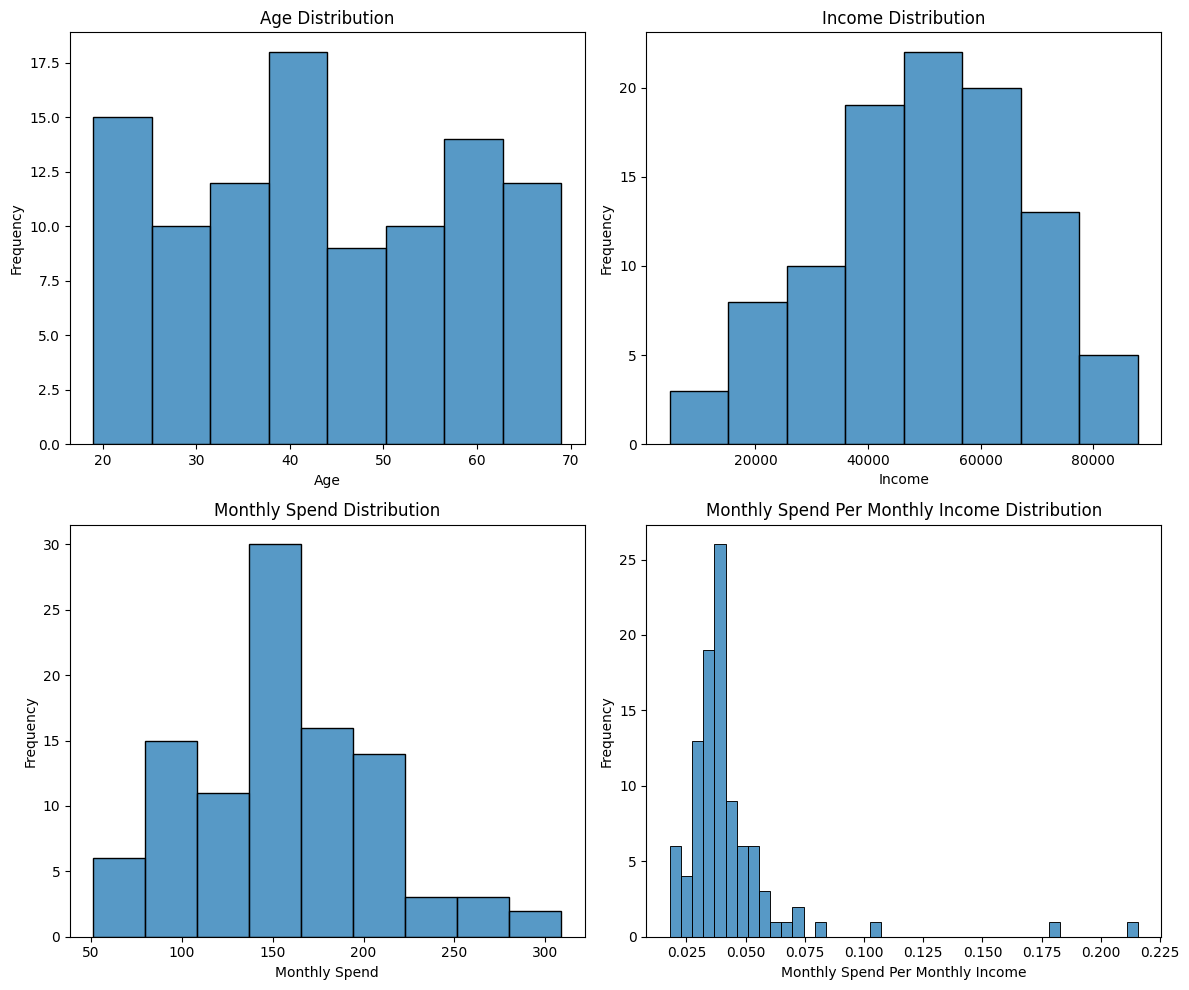

In [ ]:
import matplotlib.pyplot as plt
numerical_vars = ['age','income']

# Adjusting the size for a 2x2 grid
plt.figure(figsize=(12, 10))

# Histogram for age
plt.subplot(2, 2, 1)
sns.histplot(df['age'], kde=False)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Histogram for income
plt.subplot(2, 2, 2)
sns.histplot(df['income'], kde=False)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')

# Histogram for monthly spend
plt.subplot(2, 2, 3)
sns.histplot(df['monthly_spend'], kde=False)
plt.title('Monthly Spend Distribution')
plt.xlabel('Monthly Spend')
plt.ylabel('Frequency')

# Histogram for monthly spend per monthly income
plt.subplot(2, 2, 4)
sns.histplot(df['monthly_spend_per_monthly_income'], kde=False)
plt.title('Monthly Spend Per Monthly Income Distribution')
plt.xlabel('Monthly Spend Per Monthly Income')
plt.ylabel('Frequency')

# Ensuring layout is tight
plt.tight_layout()
plt.show()

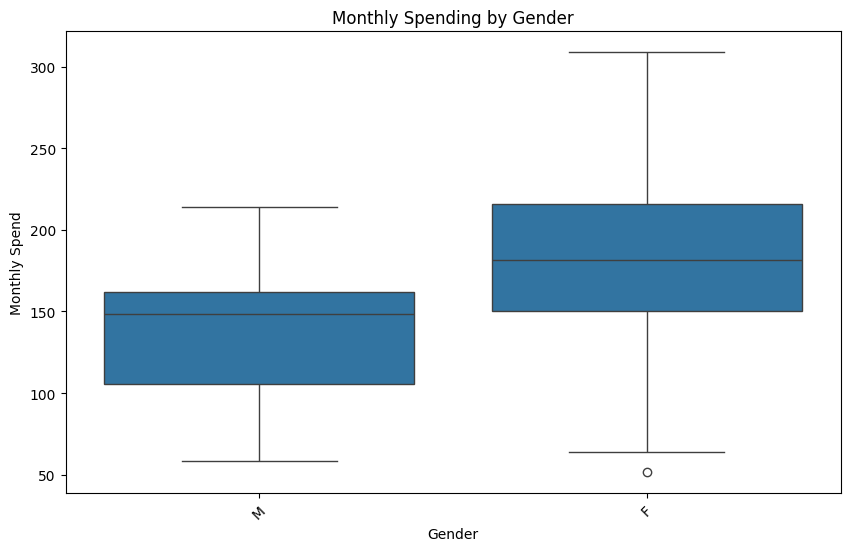

In [ ]:
# Visualization: Monthly Spend by Gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='monthly_spend', data=df)
plt.title('Monthly Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Monthly Spend')
plt.xticks(rotation=45)
plt.show()


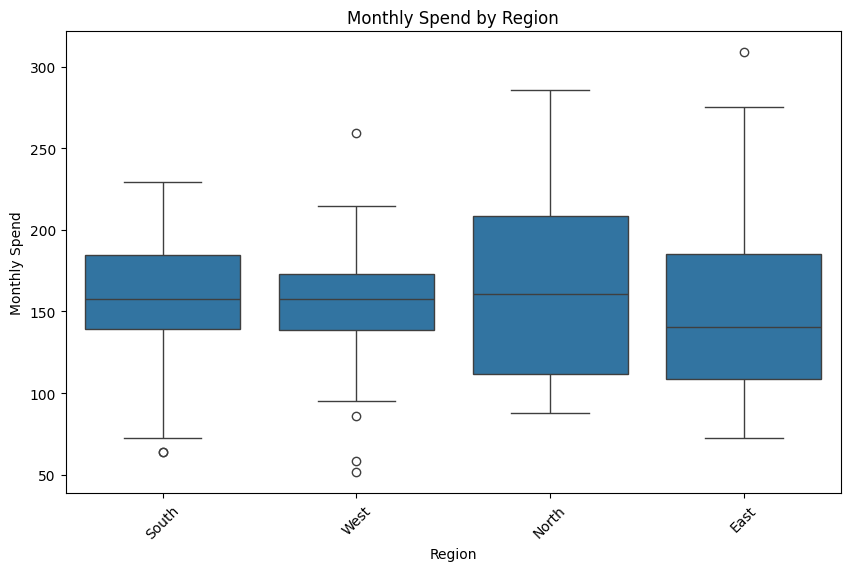

In [ ]:
# Visualization: Monthly Spend by Region
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='monthly_spend', data=df)
plt.title('Monthly Spend by Region')
plt.xlabel('Region')
plt.ylabel('Monthly Spend')
plt.xticks(rotation=45)
plt.show()

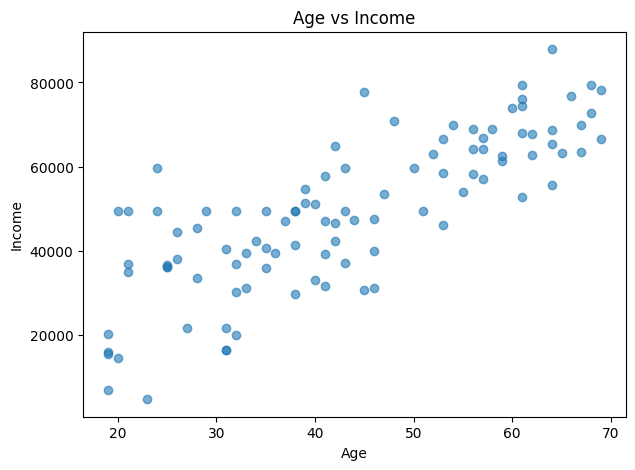

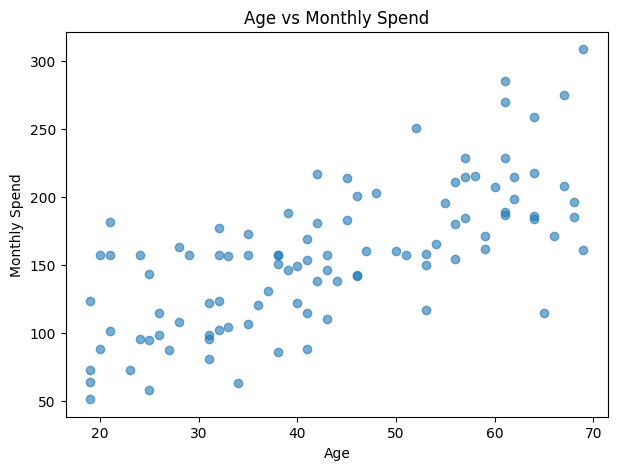

In [ ]:
# Visualization: Scatter Plots
plt.figure(figsize=(7,5))
plt.scatter(df['age'], df['income'], alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df['age'], df['monthly_spend'], alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Monthly Spend')
plt.title('Age vs Monthly Spend')
plt.show()

### Encoding Categorical Variables with Dummy Variables

Transform the categorical `gender` and `region` columns into numerical format to prepare the data for analysis.

- **Use `pd.get_dummies`:** Convert the `gender` and `region` column into dummy variables, creating separate binary columns for each gender and each region(e.g., `region_North`, `region_South`).
- **Avoid Multicollinearity:** Use the `drop_first=True` option to exclude one dummy variable, reducing redundancy and preventing issues in regression models.

This approach ensures the categorical `gender` and `region` data is represented numerically, making it compatible with statistical and machine learning models.

In [ ]:
# Encode categorical variables
df = pd.get_dummies(df, columns = ['gender','region'], drop_first = True, dtype=int)
df.head()

,customer_id,age,income,monthly_spend,monthly_spend_per_monthly_income,gender_M,region_North,region_South,region_West
0,CUST_1,56,68900.0,154.82,0.026964,1,0,1,0
1,CUST_2,69,78300.0,160.97,0.024670,1,0,0,1
2,CUST_3,46,40000.0,141.76,0.042528,1,0,0,1
3,CUST_4,32,30200.0,102.35,0.040669,1,1,0,0
4,CUST_5,60,73900.0,207.71,0.033728,1,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_id                       100 non-null    object 
 1   age                               100 non-null    int64  
 2   income                            100 non-null    float64
 3   monthly_spend                     100 non-null    float64
 4   monthly_spend_per_monthly_income  100 non-null    float64
 5   gender_M                          100 non-null    int64  
 6   region_North                      100 non-null    int64  
 7   region_South                      100 non-null    int64  
 8   region_West                       100 non-null    int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 7.2+ KB


### Visualize Correlations with a Heatmap

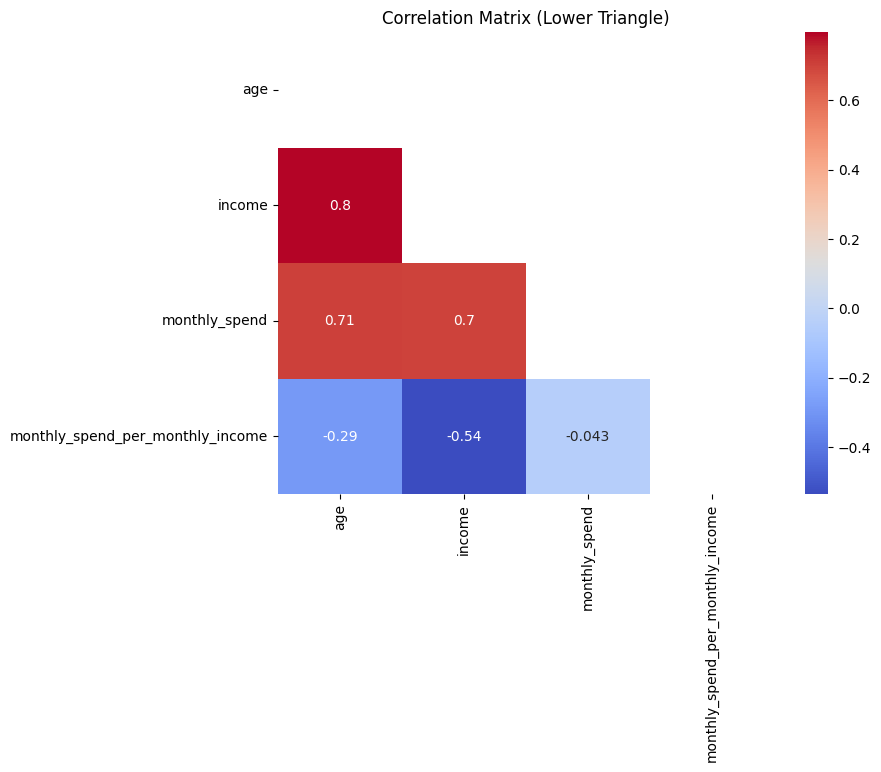

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df[['age','income','monthly_spend', 'monthly_spend_per_monthly_income']].corr()

# Create a mask to display only the lower triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Create the heatmap with the mask
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', mask=mask)
plt.title('Correlation Matrix (Lower Triangle)')
plt.show()

### Visualize the distributions and pairwise relationships

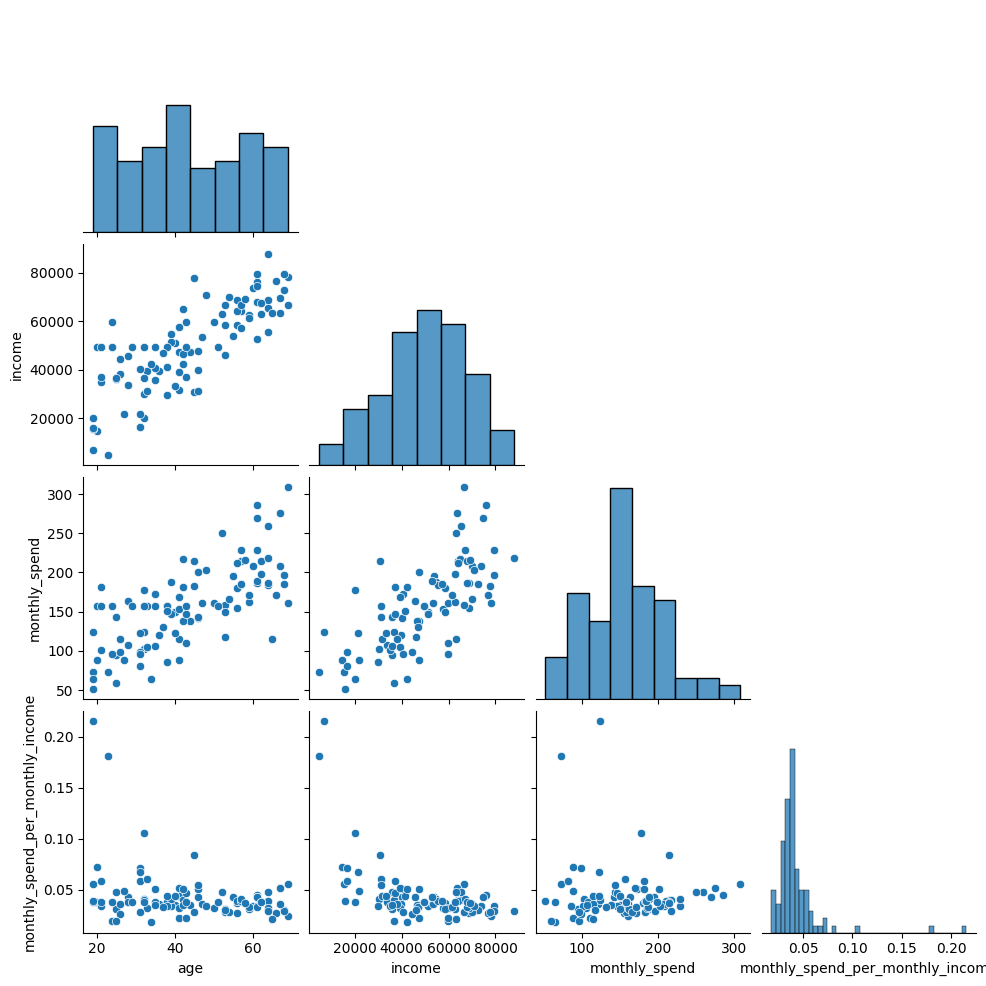

In [ ]:
# Create a pairplot using Seaborn
sns.pairplot(df[['age', 'income', 'monthly_spend', 'monthly_spend_per_monthly_income']], corner=True)
plt.show()

### Run a Linear Regression Analysis with All Variables

In [ ]:
df.head()

,customer_id,age,income,monthly_spend,monthly_spend_per_monthly_income,gender_M,region_North,region_South,region_West
0,CUST_1,56,68900.0,154.82,0.026964,1,0,1,0
1,CUST_2,69,78300.0,160.97,0.024670,1,0,0,1
2,CUST_3,46,40000.0,141.76,0.042528,1,0,0,1
3,CUST_4,32,30200.0,102.35,0.040669,1,1,0,0
4,CUST_5,60,73900.0,207.71,0.033728,1,0,1,0


In [ ]:
import statsmodels.formula.api as sm

# Define the formula for the multiple linear regression
formula = (
    'monthly_spend ~ age + income + gender_M + region_North + region_South + region_West'
)

# Fit the model
model = sm.ols(formula=formula, data=df).fit()

# Print the summary of the model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     30.97
Date:                Fri, 08 May 2026   Prob (F-statistic):           3.51e-20
Time:                        02:43:25   Log-Likelihood:                -482.08
No. Observations:                 100   AIC:                             978.2
Df Residuals:                      93   BIC:                             996.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       65.5473     12.747      5.142   

### Run the model again with only significant predictors

In [ ]:
import statsmodels.formula.api as sm

# Define the formula for the multiple linear regression
formula = (
    'monthly_spend ~  age + income + gender_M'
)

# Fit the model
model = sm.ols(formula=formula, data=df).fit()

# Print the summary of the model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     62.43
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.79e-22
Time:                        02:43:25   Log-Likelihood:                -482.87
No. Observations:                 100   AIC:                             973.7
Df Residuals:                      96   BIC:                             984.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     69.3286     11.003      6.301      0.0

### **Interpretation of Regression Results**

#### R-squared (0.661)
- **Interpretation:**
  - An R-squared of 0.661 indicates that approximately **66.1% of the variability in monthly spend** is explained by age, income and gender.
  - While this is a reasonably high value, it suggests there are other factors influencing performance scores not captured in the model.

---
#### Intercept (69.3286)
- The **intercept of 69.3286** indicates that the baseline monthly spend when all other variables are zero.

---

#### Significant Coefficients
- **Age (1.4233):**
  - For every 1-unit increase in `age`, the `monthly_spend` increases by **1.4233 points** on average, holding other variables constant.
  - In other words, a customer who is 10 years old is expected to spend about `$14.23` more per month.
  - This suggests a **strong positive relationship** between age and monthly spend.

- **Income (0.0010):**
  - For every 1-unit increase in `income`, the `monthly_spend` increases by **0.0010 points** on average, holding other variables constant.
  -  In practical terms, a customer earning `$50,000` more per year spend about `$50` more per month.
  - This suggests a **strong positive relationship** between income and monthly spend.

- **Gender_M (-35.4191):**
  - For every 1-unit decrease in `gender_M`, the `monthly_spend` increases by **-35.4191 points** on average, holding other variables constant.
  - This means that male customers spend `$35.42` less per month on average compared to female customers.
  - This suggests a **strong negative relationship** between income and monthly spend.
---
#### P-value
All three predictors are statistically significant at the p < 0.001 threshold, meaning there is very strong evidence that each variable has a real relationship with monthly spend.
- **Age (p < 0.001)**: Highly significant which means that age has a meaningful impact on monthly spend.
- **Income (p = 0.001)**: Highly significant which means that income has a meaningful impact on monthly spend.
- **Gender_M (p < 0.001)**: Highly significant which means that being male has a meaningful impact on monthly spend.



### **Business Recommendations**

- **Target marketing towards older adults:** Age is a strong predictor of monthly spend; older customers tend to spend more per month on average. The company can focus on advertising higher-end, pricier products towards older customers to drive sales, while giving younger adults access to more affordable products.

- **Leverage income-based segmentation:** Higher income is also a significant predictor of monthly spend. The company can use income to segment customers and tailor offerings; focusing on premium products for higher-income customers and value-focused promotions for lower-income ones.

- **Investigate the gender spending gap:** Female customers spend about $35 more per month compared to male customers on average, which is a meaningful difference. The company should look further into what is driving this gap — finding what each gender purchases most often — and use those findings to tailor marketing and product offerings towards each group to increase overall spending.